# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [ ]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 0.5,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 300,                                   # temperature parameter for the softmax 
     'T_crossover_ratio': 0,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': 0.8,                       # output group: [np.ceil(par['majority_ratio']*par['L']):-1]
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     #'state_bound': [-10,+10],                    # boundaries on the possibile values of the state
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.05,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.9,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 500,                    # number of iterations of the algorithm
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean, loss_ev, mean_asp = m.evolution(par,verb=3,gen_verb=False,stat=True)

Iteration #0...
Mean loss: 1.0069881470509852
Mean target distance: 1.0069881495534991
Iteration #1...
Mean loss: 1.0070459413367518
Mean target distance: 1.0070459407872727
Iteration #2...
Mean loss: 1.0070209464529203
Mean target distance: 1.007020944754101
Iteration #3...
Mean loss: 1.0070426390924674
Mean target distance: 1.0070426399838035
Iteration #4...
Mean loss: 1.0069537187416158
Mean target distance: 1.006953716188472
Iteration #5...
Mean loss: 1.006961223468898
Mean target distance: 1.0069612266206152
Iteration #6...
Mean loss: 1.0069136244911283
Mean target distance: 1.0069136227257578
Iteration #7...
Mean loss: 1.0069797775140348
Mean target distance: 1.006979778452098
Iteration #8...
Mean loss: 1.00694529603631
Mean target distance: 1.0069452970969524
Iteration #9...
Mean loss: 1.0069848746587295
Mean target distance: 1.0069848750316692
Iteration #10...
Mean loss: 1.006940189906057
Mean target distance: 1.0069401925512311
Iteration #11...
Mean loss: 1.0069485118837087
Me

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 180


In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: 0.15497651444308877
Target distance:1.3339707489151065
Link cost:0.06038330880248532
Input: [-1, 1] -> Output: -0.30007493315604766
Target distance:1.6901948318207018
Link cost:0.06038330880248532
Input: [1, -1] -> Output: 0.15428644885167678
Target distance:0.7152314105959076
Link cost:0.06038330880248532
Input: [1, 1] -> Output: -0.31278035188913894
Target distance:0.4722708447496156
Link cost:0.06038330880248532
loss:1.0529169590203329
Solution #1
Input: [-1, -1] -> Output: 0.23146151406469273
Target distance:1.5164974606225055
Link cost:0.06650132974703929
Input: [-1, 1] -> Output: 0.08977487154082738
Target distance:0.8285097844785172
Link cost:0.06650132974703929
Input: [1, -1] -> Output: 0.23134805550229834
Target distance:0.5908258117800979
Link cost:0.06650132974703929
Input: [1, 1] -> Output: -0.24328290377540385
Target distance:0.5726207637185847
Link cost:0.06650132974703929
loss:0.8771134551499264
Solution #2
Input: [-1, -1] -> Output

In [6]:
print(f'Mean final loss: {np.mean(np.array(losses))}')

Mean final loss: 0.8236517426950369


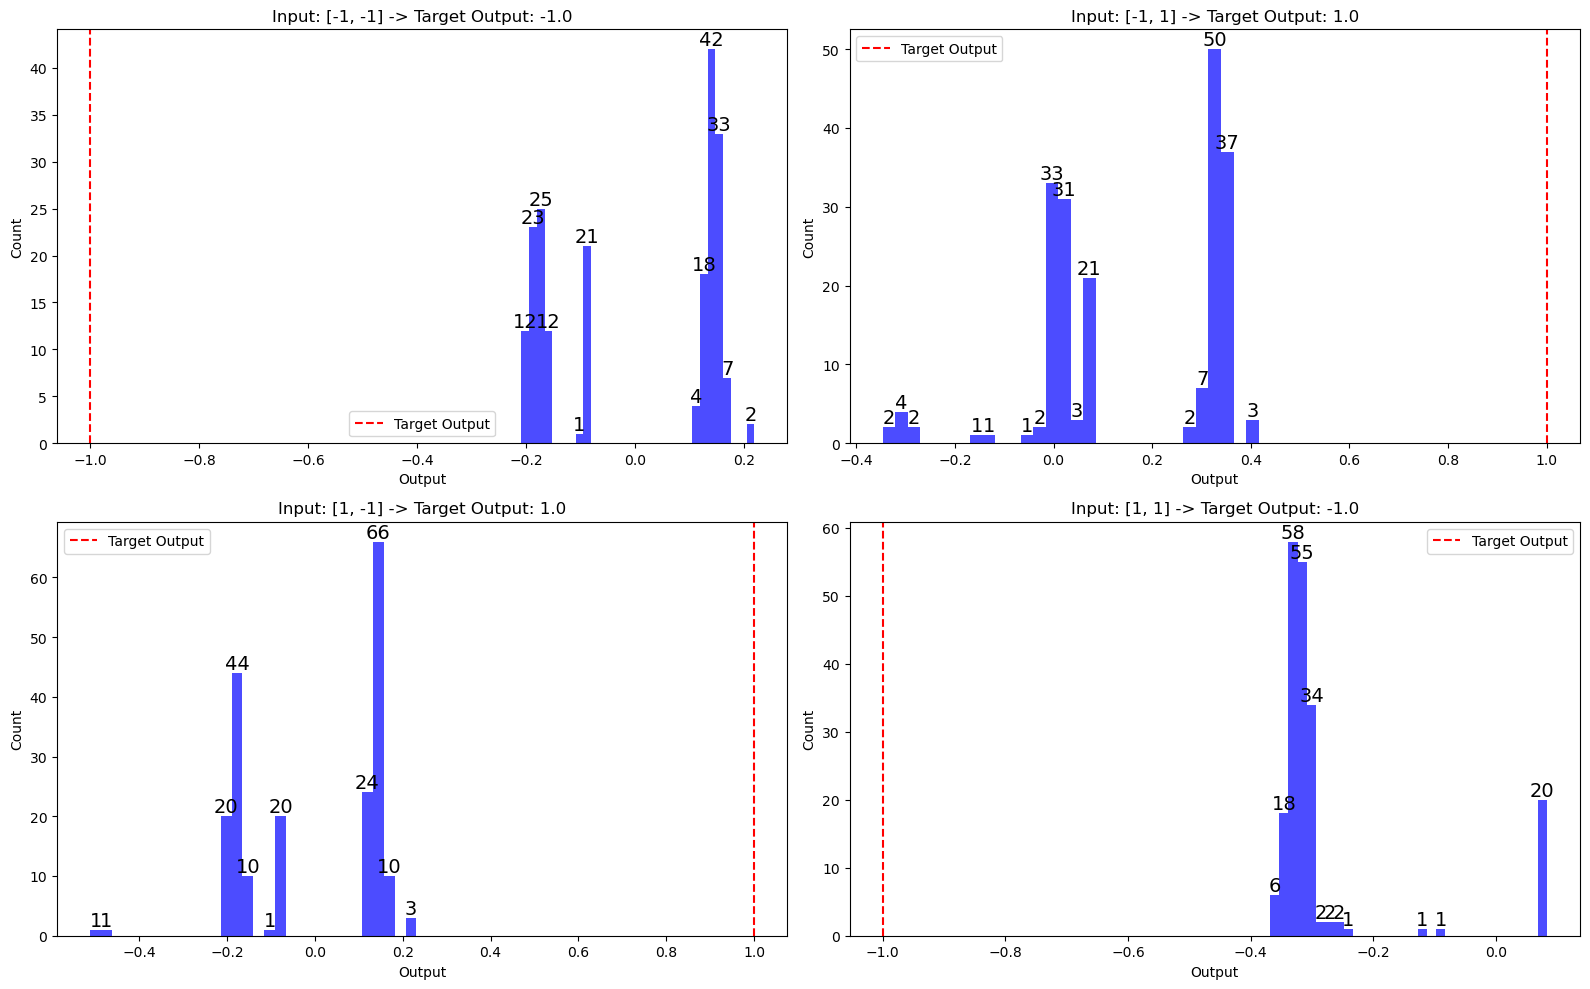

In [7]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
print(f'Vertex numbers of inputs: 0,{par['L']}')
print(f'Vertex numbers of the output: {par['L']**2-1}')

Vertex numbers of inputs: 0,4
Vertex numbers of the output: 15


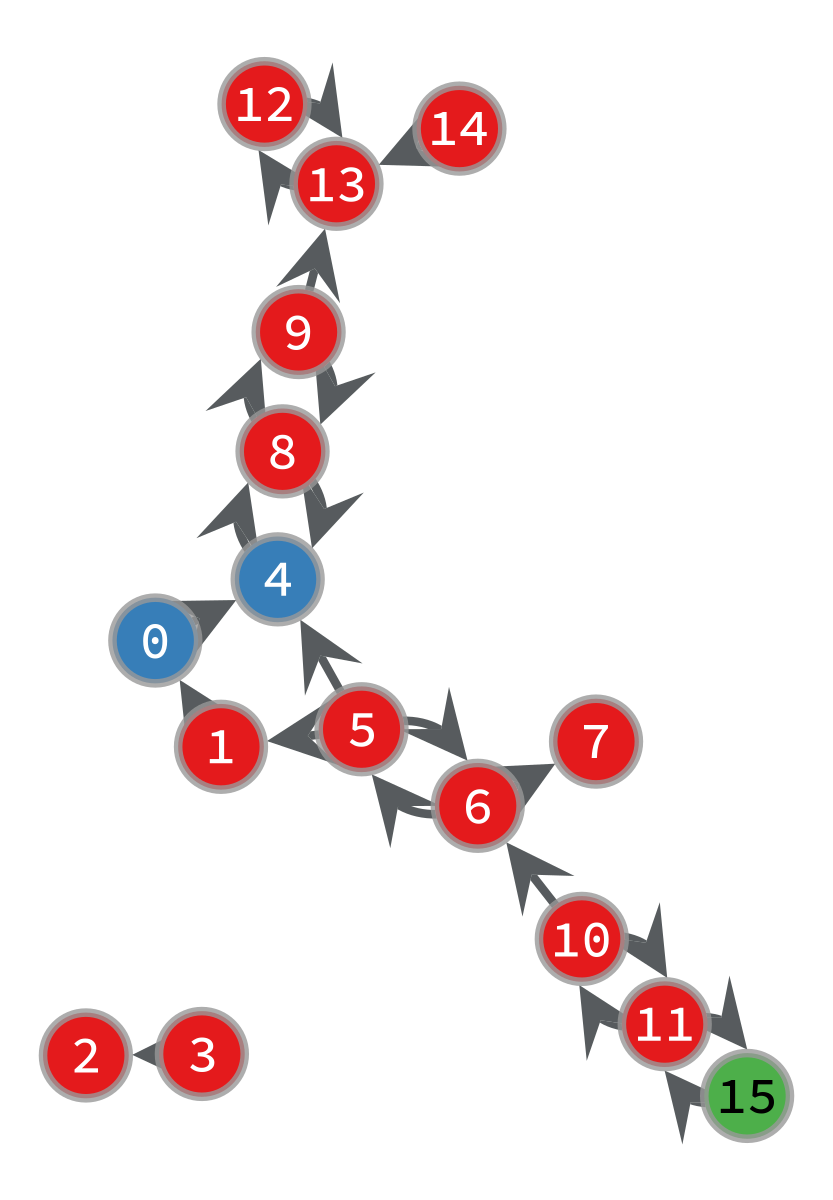

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f38924dcd70, at 0x7f388a161ef0>

In [9]:
graph = solutions[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex(par['L'])] = 1
highlight[graph.vertex(graph.num_vertices()-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [10]:
print(f'Links density:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Links density:0.08203125


In [11]:
for input in par['input_set']:
    output,_ = m.ff(input,s[2],par,verb=2)
    print(f'Input:{input} -> Output:{output}')

Input:[-1, -1] -> Output:0.15167581098060512
Input:[-1, 1] -> Output:0.01830244789089076
Input:[1, -1] -> Output:0.15131169823286006
Input:[1, 1] -> Output:-0.3174283381298812


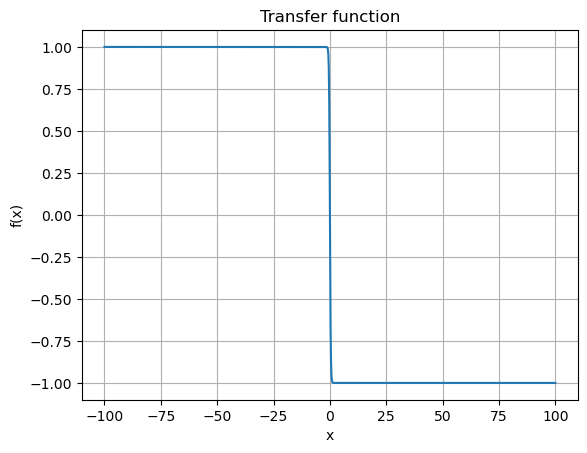

In [12]:
m.plot_T(s[0].T[5],par)

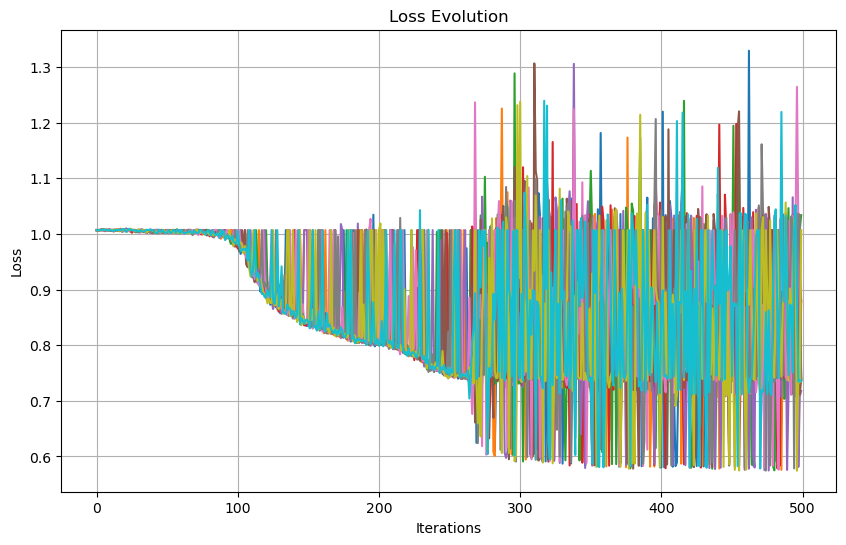

In [13]:
plt.figure(figsize=(10, 6))
for s in range(loss_ev.shape[0]//20):
    plt.plot(loss_ev[s,:],label=f'Solution#{s}')
plt.title('Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Loss')
#plt.ylim(0.9999, 1.001)
#plt.yscale('log')
#plt.xscale('log')
#plt.legend()
plt.grid(True)
plt.show()

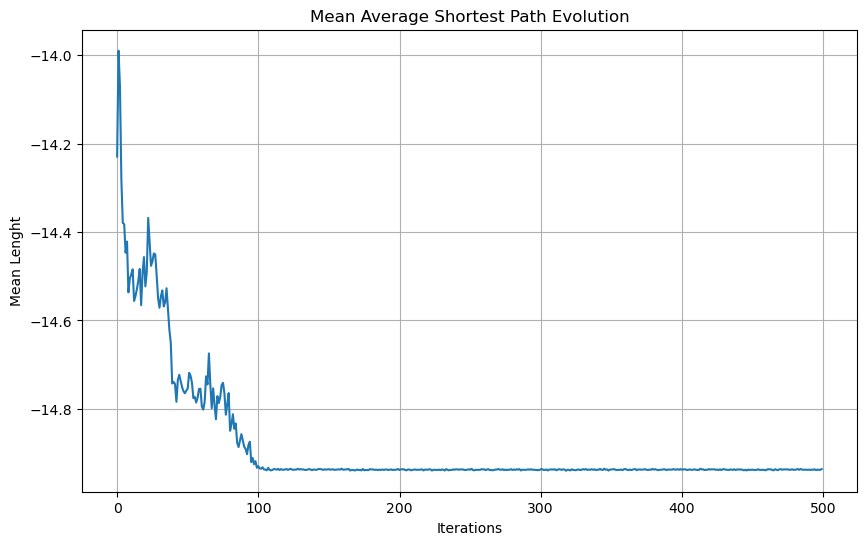

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(mean_asp)
plt.title('Mean Average Shortest Path Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Lenght')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

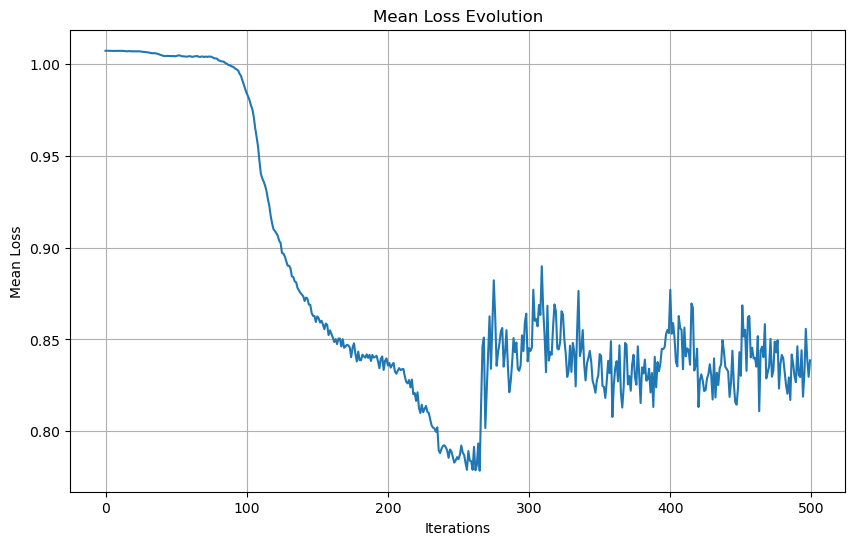

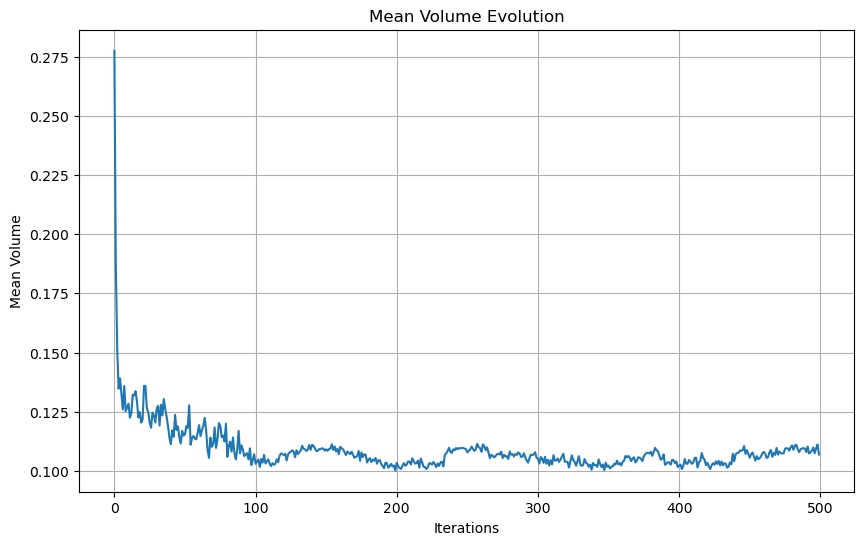

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(par['n_iter']),lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

'''
plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()
'''

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()